In [45]:
# copy and paste the lines needed to read in the large galaxy zoo catalog from the first observed galaxies notebook
import pandas as pd
import numpy as np
galaxyzoo = pd.read_csv('../Data/galaxyzoo_research.csv')
galaxyzoo

,OBJID,RA,DEC,REDSHIFT,P_ELLIPTICAL,P_SPIRAL,UMAG,GMAG,RMAG,IMAG,ZMAG,LOG_MASS,R90_ARCSEC,AXIAL_RATIO,LOCAL_DENSITY,NEARCLUSTER_DIST,NEARCLUSTER_MASS
0,5.880180e+17,218.580808,8.161055,0.053766,0.530869,0.437261,-18.684864,-20.204231,-20.955414,-21.298212,-21.558670,10.516412,6.294165,0.368354,-0.1800,-999.000000,-9.990000e+02
1,5.877300e+17,239.931122,3.644782,0.054367,0.000000,0.961538,-20.101736,-21.384073,-21.838770,-21.980230,-22.158155,10.592430,14.513707,0.799851,-0.2080,15.959925,5.430000e+12
2,5.877242e+17,10.641342,15.445178,0.079503,0.470876,0.491672,-19.834967,-21.217686,-21.850147,-22.147160,-22.348995,10.828524,7.862754,0.879052,0.8070,1.059320,3.940000e+14
3,5.877415e+17,165.379954,28.187846,0.069913,0.532013,0.424623,-19.435511,-20.811283,-21.509943,-21.847149,-22.106108,10.672685,6.840029,0.930676,0.0285,-999.000000,-9.990000e+02
4,5.877300e+17,216.307612,-1.099459,0.055574,0.647059,0.088235,-18.376757,-19.623747,-20.199842,-20.470566,-20.681120,9.964785,3.187091,0.831526,0.1040,11.604042,3.740000e+13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,5.877334e+17,231.967240,50.455685,0.073404,0.946228,0.019281,-19.803755,-21.573761,-22.339725,-22.708660,-22.984587,11.098833,8.970359,0.721744,-0.5390,12.696922,1.450000e+14
19996,5.880177e+17,243.777330,6.092806,0.059610,0.758621,0.000000,-16.315529,-20.404915,-21.282505,-21.124458,-22.213829,11.365675,13.147679,0.741964,-0.5400,-999.000000,-9.990000e+02
19997,5.877250e+17,184.644965,-1.598657,0.079722,0.129100,0.562271,-19.415325,-20.450088,-20.837673,-20.960474,-21.146212,10.002666,5.776074,0.621813,-0.6670,19.389032,6.630000e+14
19998,5.877258e+17,118.714675,45.705057,0.052579,0.837452,0.064308,-19.477306,-21.262995,-22.042334,-22.473787,-22.752541,10.986648,11.711008,0.841293,1.4600,0.000000,8.510000e+13


**Copy and paste your table for the descriptions of the columns**

| Column Header | Definition | Unit |
| :- | :- | :- |
| OBJID | name/identifier of the galaxy | n/a
| P_ELLIPTICAL |  | 
| P_SPIRAL|  | 
| UMAG| brigtness of u-band(filter) | magnitude (bigger = dimmer)
| GMAG| brigtness of g-band(filter) | magnitude (bigger = dimmer)
| RMAG| brigtness of r-band(filter) | magnitude (bigger = dimmer)
| IMAG| brigtness of i-band(filter) | magnitude (bigger = dimmer)
| ZMAG| brigtness of z-band(filter) | magnitude (bigger = dimmer)
| LOG_MASS| log(mass of galaxy) | log(Solar Mass)


## Galaxy Zoo Types

We only tested a couple of tens of galaxies, but there are billions in the Universe! We can expand our sample by using the full galaxy zoo data that we read in earlier. It still only has a small subsample of galaxies, but 20,000 is much bigger than 20!

Just like before, let's say a galaxy is elliptical if it is classified as elliptical 80% of the time, and that it is a sprial if it is classified as spiral 80% of the time. This means we want the probability to be equal to or greater than 0.8. Pull out the relevant probabilities from the big Galaxy Zoo catalog. Make sure you aren't repeating variable names!

In [21]:
# grabbing the Galaxy Zoo probability columns
gz_prob_elliptical = galaxyzoo['P_ELLIPTICAL']
gz_prob_spiral = galaxyzoo['P_SPIRAL']
total_class = len(gz_prob_elliptical)

In [22]:
# make Boolean arrays based on the probabilites above

# Show probability greater than 0.8 for elliptical galaxies
greater_e = gz_prob_elliptical>=0.8
greater_e

# Show probability greater thann 0.8 for spiral galaxies
greater_s = gz_prob_spiral>=0.8
greater_s

0        False
1         True
2        False
3        False
4        False
         ...  
19995    False
19996    False
19997    False
19998    False
19999    False
Name: P_SPIRAL, Length: 20000, dtype: bool

In [23]:
# the sum of the Boolean arrays tell us how many galaxies passed each test

print('The number of elliptical galaxies is', sum(greater_e)) # fill in the sum after the comma
print('The number of spiral galaxies is', sum(greater_s)) # fill in the sum after the comma
print('The total number of galaxies classifed is', len(gz_prob_elliptical))

The number of elliptical galaxies is 2509
The number of spiral galaxies is 6881
The total number of galaxies classifed is 20000


**How do the results of your data and the full Galaxy Zoo data compare? (Go back to Observed Galaxies Pt2 to see your results)**

**Answer:** There sre still more identified spiral galaxies than elliptical

It is not super fair for us to compare the number of elliptical/spirals in each data group because the sizes are very different. Let's calculate the percent of each type of galaxy in the two data groups. Remember, we can calculate the percent of something by doing: $\rm \frac{number\ of\ specific}{total} \times 100$

Calcualte and compare the 4 percents below.

In [26]:
# first we need to bring in the data you created in the last notebook. copy and paste the lines of code to read in that data
my_data = pd.read_csv('../Data/galazyzoo_experiment.csv')
my_data

,Galaxy ID,Total # of classifications,Elliptical,Spiral,Merger,Artifact,SSDS ID,Image,GZ Original Elliptical,GZ Original Spiral,GZ Original Merger,GZ Original Artifact,Computer Classification
0,1,10,0,10,0,0,1237648720142336185,http://skyserver.sdss.org/dr8/en/tools/explore...,0,37,0,0,Not Elliptical
1,2,10,6,3,1,0,1237648721215815838,http://skyserver.sdss.org/dr8/en/tools/explore...,3,53,1,0,Not Elliptical
2,3,10,2,8,0,0,1237648721215946942,http://skyserver.sdss.org/dr8/en/tools/explore...,5,58,0,0,Not Elliptical
3,4,10,8,0,1,1,1237648721216078045,http://skyserver.sdss.org/dr8/en/tools/explore...,35,0,0,0,Elliptical
4,5,10,5,4,0,1,1237648721216078463,http://skyserver.sdss.org/dr8/en/tools/explore...,0,31,0,1,Not Elliptical
5,6,10,0,1,9,0,1237648721245503521,http://skyserver.sdss.org/dr8/en/tools/explore...,1,0,25,1,Elliptical
6,7,10,0,10,0,0,1237648722295914556,http://skyserver.sdss.org/dr8/en/tools/explore...,0,23,0,0,Not Elliptical
7,8,10,7,0,0,3,1237650795146576091,http://skyserver.sdss.org/dr8/en/tools/explore...,38,1,0,3,Unable to Determine
8,9,10,8,0,0,2,1237650795683381426,http://skyserver.sdss.org/dr8/en/tools/explore...,63,2,0,0,Unable to Determine
9,10,10,0,10,0,0,1237650796219596962,http://skyserver.sdss.org/dr8/en/tools/explore...,0,26,0,0,Not Elliptical


In [32]:
# copy and paste ALL lines of code after you printed the data table. (You can ignore the print statements at the end.)

# pull out the columns that are relevant
total = my_data['Total # of classifications']
elliptical_num = my_data['Elliptical']
spiral_num = my_data['Spiral']

# fill in the following code to calculate the probability of a galaxy being a spiral or an elliptical 
prob_elliptical = elliptical_num / total
prob_spiral = spiral_num / total

# set up the Boolean arrays 
elliptical = prob_elliptical >= 0.8
spiral = prob_spiral >= 0.8
print(elliptical)

# the sum of the Boolean arrays tell us how many galaxies passed each test
print('The number of elliptical galaxies is', sum(elliptical)) # fill in the sum after the comma
print('The number of spiral galaxies is', sum(spiral)) # fill in the sum after the comma
print('The total number of galaxies classifed is', len(total))

0     False
1     False
2     False
3      True
4     False
5     False
6     False
7     False
8      True
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16     True
17    False
18    False
19    False
20    False
21    False
dtype: bool
The number of elliptical galaxies is 3
The number of spiral galaxies is 6
The total number of galaxies classifed is 22


In [35]:
# now calculate the percents

# my data
ell_per = sum(elliptical)/ len(total)*100
spi_per = sum(spiral) / len(total) *100

# galaxy zoo
ell_per2 = sum(greater_e)/ len(galaxyzoo['OBJID'])*100
spi_per2 = sum(greater_s) / len(galaxyzoo['OBJID']) *100

# print the results -- fill in the name of the appropriate variable in between the commas in the print statments
print('For my data:')
print('The percentage of elliptical galaxies is', ell_per, '%')
print('The percentage of spiral galaxies is',spi_per, '%')
print('')
print('For all of the Galaxy Zoo data:')
print('The percentage of elliptical galaxies is',ell_per2, '%')
print('The percentage of spiral galaxies is',spi_per2, '%')

For my data:
The percentage of elliptical galaxies is 13.636363636363635 %
The percentage of spiral galaxies is 27.27272727272727 %

For all of the Galaxy Zoo data:
The percentage of elliptical galaxies is 12.545 %
The percentage of spiral galaxies is 34.405 %


**How do the percentages between the two data sets compare?**

**Answer:** Percents for ellipticals are very close to eachother but there is a gap between spiral

## Galaxy Evolution

Like stars, galaxies form when super massive clouds of gas collapse because of gravity. These super massive clouds form stars overtime, and that creates a galaxy. 

Galaxies grow overtime through merging with other galaxies. Similarly to a business merger, this involves at least two galaxies coming together to form a bigger galaxy. Here is a video (https://www.youtube.com/watch?v=SZfOyyGMSGg&ab_channel=VideoFromSpace) showing images of galaxies in the process of merging. Note how they don't have a clear spiral or elliptical shape. This video (https://www.youtube.com/watch?v=lXy3B2K47Qg&ab_channel=VideoFromSpaceVideoFromSpaceVerified) shows computer images matched with real images of galaxies in the process of merging. The merging process takes billions of years, so we cannot watch it happen, which is why we need computers to know what the process looks like. The fact that images from the computer matches real images we see from space gives us confidence that the computer images are accurate!

(I like to think about this as "galactic cannibalism" and that galaxies grow by eating other galaxies.) Galaxies do this A LOT. Our own Milky Way has eaten many small galaxies over time. Below are computer images showing how this could work. 

<br>
<center>
<div>
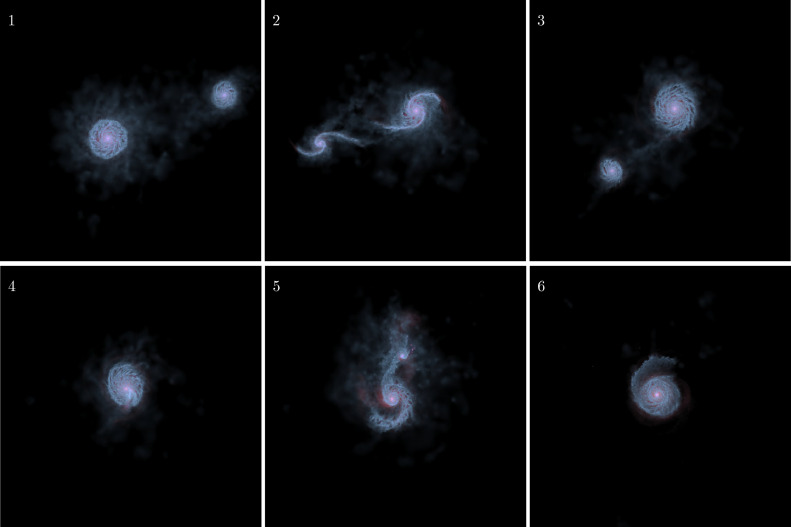
<div>
<center>    
    
<center>
Computer images of a galaxy and a smaller galaxy merger across panels 1-6. Note how the final galaxy doesn't look too different from the initial bigger galaxy. The more massive one "wins," and the smaller one is destroyed and eaten by the bigger one.
<center>
    
    
    
<br>
    
    
When two galaxies that have similar masses merge, they form a totally new galaxy that doesn't always look like one of the originals. This is especially true when two spiral galaxies of the same mass merge. They lose their spiral arms and get puffed out, resulting in a galaxy that looks like an ...elliptical galaxy! In fact, this is how we think elliptical galaxies are formed! Check out this vide of two spiral galaxies merge: https://www.youtube.com/watch?v=QcDtJ_-jdMw&ab_channel=HubbleSpaceTelescope
    
Here is a video (https://www.youtube.com/watch?v=4disyKG7XtU&ab_channel=VideoFromSpace) showing a computer-made video of what will happen in billions of years when the Milky Way and its large neighbor the Andromeda Galaxy collide. 

**What are some observations you notice from the two above videos?**

**Observations:** 2 spiral galaxies collide and make an elliptical galaxy

## Deliverable: Ellipticals vs Spirals Ages

Let's think about the ages of spiral galaxies and elliptical galaxies. It is hard to know the age of a galaxy, so we can focus on general trends.

**Based on the information above, which type of galaxy do you think tend to be older?**

**Your hypothesis:** Elliptical

How could you test your hypothesis? What data do you have in the galaxy zoo catalog that you could use? **Explain below.** And then experiment!

**Explanation:** 

**In your propsed explanation, what would be the independent variable?** 
Elliptical and Spiral

**In your propsed explanation, what would be the dependent variable?** 
g band-r band

Below add your code to test your hypothesis. Have a clearly labeled plot that you are ready to present to the group. Add statistics to your findings by exploring the mean and standard deviation of your results.

The mean color of spiral galaxies is 0.58
The mean color of elliptical galaxies is 0.75

The standard deviation of the color of spiral galaxies is 0.13
The standard deviation of the color of elliptical galaxies is 0.08


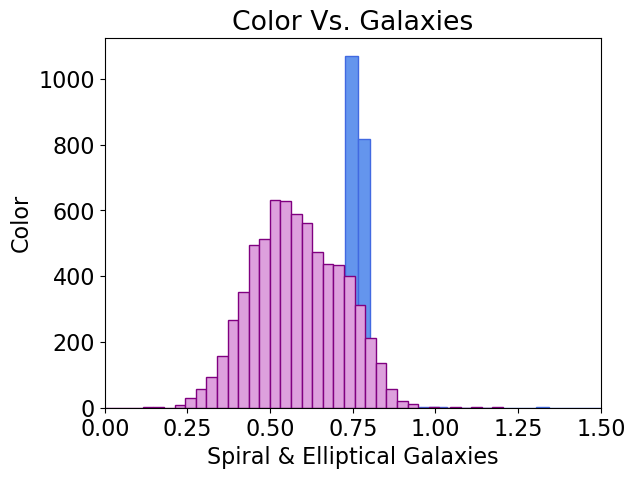

In [70]:
# add your code below to test your hypothesis

# import our graphing package
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

#the below is optional but makes the font a size I can read more easily
import matplotlib
matplotlib.rc('font', **{'family':'sans-serif', 'size':16}) 

#get data needed for color
g_band = galaxyzoo['GMAG']
r_band = galaxyzoo['RMAG']

color = g_band - r_band

# separate color into elliptical and spiral galaxies
elliptical = color[greater_e] 
spiral = color[greater_s]

# create one histogram with elliptical and spiral galaxies on it
plt.hist(elliptical, bins = 100, color ='cornflowerblue', edgecolor = 'royalblue')
plt.hist(spiral, bins = 50, color = 'plum', edgecolor = 'purple')
plt.title('Color Vs. Galaxies')
plt.xlabel('Spiral & Elliptical Galaxies')
plt.ylabel('Color')
plt.xlim(0,1.5)
plt.ylim()

# statistics

#fill in the appropriate numpy function and code where the $ is below
print('The mean color of spiral galaxies is', round(np.mean(spiral), 2))
print('The mean color of elliptical galaxies is', round(np.mean(elliptical), 2))
print('')
print('The standard deviation of the color of spiral galaxies is', round(np.std(spiral), 2))
print('The standard deviation of the color of elliptical galaxies is', round(np.std(elliptical), 2))


**What are your results?**

**Answer:** Elliptical galaxies are older but spirals have more age variation

**What conclusion can you make from your results?**

**Answer:** Elliptical galaxies tend to get older than spiral galaxies but, they also have more age variation

**Is this consistent with what you learned about galaxy mergers and evolution?**

**Answer:** Yes

## Reflection

We are going to move on from galaxies observations and start talking about galaxy simulations. Before we do so, write down some notes in your lab notebook about what you've learned in this unit. Be sure to include some astronomy and some coding. 